In [1]:
import sys
from pathlib import Path
import pandas as pd

# Repo root (works if cwd is project root or refined_tables/)
for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "pyproject.toml").exists():
        sys.path.insert(0, str(_p))
        break

from injestion.core.bq import get_client
from injestion.core.env import load_env
from injestion.sportradar import SportradarManager

load_env()

client = get_client()
_rankings_table = SportradarManager().get_table_id("rankings")


In [2]:
def get_rankings_data() -> pd.DataFrame:
    _rankings_table = SportradarManager().get_table_id("rankings")
    query = f"""
    SELECT *
    FROM `{_rankings_table}`
    WHERE generated_at = (SELECT MAX(generated_at) FROM `{_rankings_table}`)
    ORDER BY ranking_name, rank
    """
    return client.query(query).to_dataframe()

rankings_latest = get_rankings_data()


In [3]:
womens_rankings = rankings_latest[rankings_latest["gender"] == "women"].reset_index(drop=True)
mens_rankings = rankings_latest[rankings_latest["gender"] == "men"].reset_index(drop=True)

<Axes: >

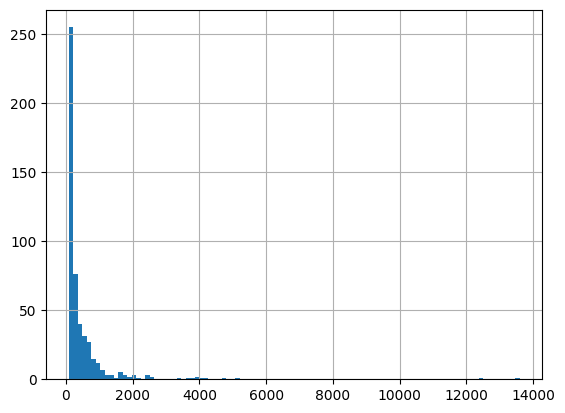

In [4]:
mens_rankings['points'].hist(bins=100)

_____
## Initialized ELO

Initial ELO set from the current ATP points ranking. This does not include all players (only players accumulated points from ATP tournaments over the last year). Unranked players will be randomly initialized using a normal distribution one standard deviation below the lowest initialized ELO ranked player.

In [5]:
from refined_tables.elo import (
    EloInitConfig,
    build_initial_elo_table,
    competitors_with_elo_init,
    elo_init_for_competitor_id,
    points_for_competitor_id,
    sample_unranked_elo_init,
)

# Slim input: name, id, points (works for any gender / list you pass in)
mens_slim = mens_rankings[["competitor_name", "competitor_id", "points"]].copy()

elo_cfg = EloInitConfig(
    elo_init_min=30.0,
    elo_init_max=90.0,
    shrink_lambda=0.65,
    shrink_mu="median",
    random_seed=42,
)

mens_elo_init = build_initial_elo_table(mens_slim, config=elo_cfg)

# Intermediate columns for plots: p_lo_used, p_hi_used, points_score_u, elo_raw, shrink_mu_used, elo_after_shrink, elo_init
mens_elo_init[["competitor_name", "points", "points_score_u", "elo_raw", "elo_after_shrink", "elo_init"]].head(12)

,competitor_name,points,points_score_u,elo_raw,elo_after_shrink,elo_init
0,"Alcaraz, Carlos",13590,1.000000,90.000000,72.810297,72.810297
1,"Sinner, Jannik",12400,0.981901,88.914074,72.104445,72.104445
2,"Zverev, Alexander",5205,0.810462,78.627720,65.418314,65.418314
3,"Djokovic, Novak",4720,0.791146,77.468786,64.665007,64.665007
4,"Musetti, Lorenzo",4265,0.771129,76.267746,63.884332,63.884332
5,"de Minaur, Alex",4095,0.763097,75.785812,63.571074,63.571074
6,"Auger-Aliassime, Felix",4000,0.758462,75.507707,63.390306,63.390306
7,"Fritz, Taylor",3870,0.751937,75.116248,63.135858,63.135858
8,"Shelton, Ben",3860,0.751427,75.085593,63.115932,63.115932
9,"Medvedev, Daniil",3610,0.738204,74.292262,62.600267,62.600267


In [6]:
mens_slim

,competitor_name,competitor_id,points
0,"Alcaraz, Carlos",sr:competitor:407573,13590
1,"Sinner, Jannik",sr:competitor:225050,12400
2,"Zverev, Alexander",sr:competitor:57163,5205
3,"Djokovic, Novak",sr:competitor:14882,4720
4,"Musetti, Lorenzo",sr:competitor:359602,4265
...,...,...,...
495,"Dellavedova, Matthew",sr:competitor:196440,86
496,"Elias, Gastao",sr:competitor:15858,85
497,"Arutiunian, Erik",sr:competitor:837590,85
498,"Ayeni, Alafia",sr:competitor:222628,85


In [7]:
# Slim input: name, id, points (works for any gender / list you pass in)
womens_slim = womens_rankings[["competitor_name", "competitor_id", "points"]].copy()

elo_cfg = EloInitConfig(
    elo_init_min=30.0,
    elo_init_max=90.0,
    shrink_lambda=0.65,
    shrink_mu="median",
    random_seed=42,
)

womens_elo_init = build_initial_elo_table(womens_slim, config=elo_cfg)

# Intermediate columns for plots: p_lo_used, p_hi_used, points_score_u, elo_raw, shrink_mu_used, elo_after_shrink, elo_init
womens_elo_init[["competitor_name", "points", "points_score_u", "elo_raw", "elo_after_shrink", "elo_init"]].head(12)

,competitor_name,points,points_score_u,elo_raw,elo_after_shrink,elo_init
0,"Sabalenka, Aryna",11025,1.000000,90.000000,73.242963,73.242963
1,"Rybakina, Elena",8108,0.933573,86.014403,70.652325,70.652325
2,"Gauff, Coco",7278,0.910231,84.613834,69.741955,69.741955
3,"Swiatek, Iga",7263,0.909785,84.587078,69.724563,69.724563
4,"Pegula, Jessica",6243,0.877075,82.624516,68.448898,68.448898
5,"Anisimova, Amanda",6180,0.874883,82.492983,68.363401,68.363401
6,"Svitolina, Elina",3965,0.778961,76.737684,64.622457,64.622457
7,"Paolini, Jasmine",3907,0.775777,76.546599,64.498252,64.498252
8,"Mboko, Victoria",3531,0.753908,75.234483,63.645377,63.645377
9,"Andreeva, Mirra",3121,0.727234,73.634047,62.605093,62.605093


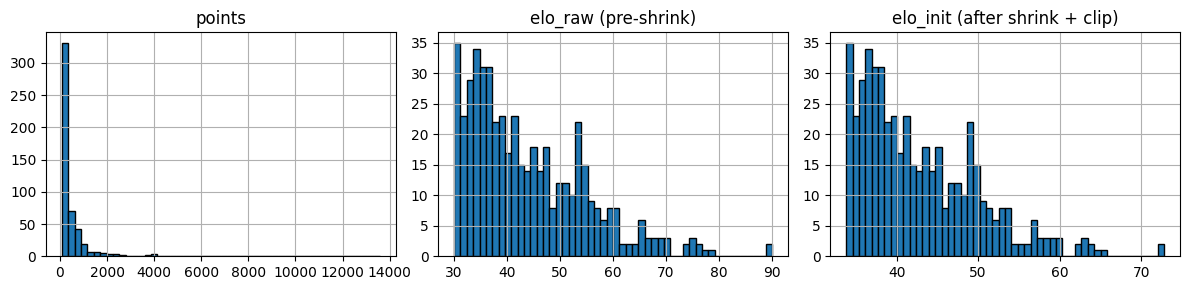

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
mens_elo_init["points"].hist(bins=50, ax=axes[0], edgecolor="black")
axes[0].set_title("points")
mens_elo_init["elo_raw"].hist(bins=50, ax=axes[1], edgecolor="black")
axes[1].set_title("elo_raw (pre-shrink)")
mens_elo_init["elo_init"].hist(bins=50, ax=axes[2], edgecolor="black")
axes[2].set_title("elo_init (after shrink + clip)")
plt.tight_layout()
plt.show()

In [9]:
# Lookup by competitor_id: ranked vs unranked random prior
examples = [
    ("sr:competitor:407573", "Alcaraz"),  # top of snapshot
    ("sr:competitor:225050", "Sinner"),
    ("sr:competitor:000000000", "not in table"),
]
for cid, label in examples:
    pts = points_for_competitor_id(cid, mens_slim)
    elo, src = elo_init_for_competitor_id(cid, mens_elo_init, config=elo_cfg)
    print(f"{label!r} ({cid}): points={pts}, elo_init={elo:.2f} ({src})")

rng = elo_cfg.make_rng()
print("unranked samples:", [round(sample_unranked_elo_init(elo_cfg, rng), 2) for _ in range(5)])

'Alcaraz' (sr:competitor:407573): points=13590.0, elo_init=72.81 (ranked)
'Sinner' (sr:competitor:225050): points=12400.0, elo_init=72.10 (ranked)
'not in table' (sr:competitor:000000000): points=None, elo_init=31.91 (unranked)
unranked samples: [31.91, 27.88, 33.25, 33.82, 25.15]


In [10]:
def get_competitors_data() -> pd.DataFrame:
    event_summary_table_id = SportradarManager().get_table_id("event_summary")
    query = f"""
    SELECT DISTINCT competitor_name, competitor_id, gender
    FROM (
    SELECT 
        home_competitor_name AS competitor_name,
        home_competitor_id as competitor_id,
        competition_gender as gender
    FROM `{event_summary_table_id}`
    WHERE competition_type = 'singles'
    UNION ALL
    SELECT 
        away_competitor_name AS competitor_name, 
        away_competitor_id as competitor_id,
        competition_gender as gender
    FROM `{event_summary_table_id}`
    WHERE competition_type = 'singles'
    )
    """
    return client.query(query).to_dataframe()

competitors = get_competitors_data()


In [11]:
mens_competitors = competitors[competitors["gender"] == "men"].reset_index(drop=True)
womens_competitors = competitors[competitors["gender"] == "women"].reset_index(drop=True)

In [12]:
# Elo init for every men's singles competitor (ranked snapshot + unranked prior for others)
# Skip the next line if you already define mens_competitors elsewhere.
mens_competitors = competitors[competitors["gender"] == "men"].drop_duplicates(
    subset="competitor_id"
).reset_index(drop=True)

mens_competitors_with_elo = competitors_with_elo_init(
    mens_competitors,
    mens_elo_init,
    config=elo_cfg,
)
mens_competitors_with_elo.head()


,competitor_name,competitor_id,gender,ranking_points,p_lo_used,p_hi_used,points_score_u,elo_raw,shrink_mu_used,elo_after_shrink,elo_init,elo_init_source
0,"Carballes Baena, Roberto",sr:competitor:51141,men,379,85.0,13590.0,0.293478,47.608667,40.886561,45.25593,45.255930,ranked
1,"Gomez-Herrera, Carlos",sr:competitor:16972,men,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,31.914151,unranked
2,"Jaziri, Malek",sr:competitor:15853,men,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,27.880048,unranked
3,"Smith, John-Patrick",sr:competitor:17038,men,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,33.251354,unranked
4,"Mager, Gianluca",sr:competitor:69500,men,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,33.821694,unranked


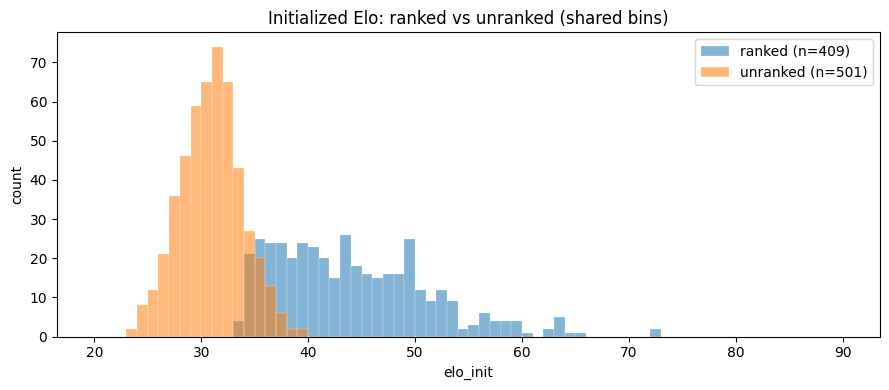

In [13]:
import matplotlib.pyplot as plt
import numpy as np

df = mens_competitors_with_elo
bins = np.linspace(20, 90, 71)
ranked = df.loc[df["elo_init_source"] == "ranked", "elo_init"]
unranked = df.loc[df["elo_init_source"] == "unranked", "elo_init"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    ranked,
    bins=bins,
    alpha=0.55,
    color="tab:blue",
    label=f"ranked (n={len(ranked):,})",
    edgecolor="white",
    linewidth=0.3,
)
ax.hist(
    unranked,
    bins=bins,
    alpha=0.55,
    color="tab:orange",
    label=f"unranked (n={len(unranked):,})",
    edgecolor="white",
    linewidth=0.3,
)
ax.set_xlabel("elo_init")
ax.set_ylabel("count")
ax.legend(frameon=True)
ax.set_title("Initialized Elo: ranked vs unranked (shared bins)")
plt.tight_layout()
plt.show()


In [14]:
mens_competitors_with_elo.sort_values(by='elo_init', ascending=False).head(10)

,competitor_name,competitor_id,gender,ranking_points,p_lo_used,p_hi_used,points_score_u,elo_raw,shrink_mu_used,elo_after_shrink,elo_init,elo_init_source
373,"Alcaraz, Carlos",sr:competitor:407573,men,13590,85.0,13590.0,1.000000,90.000000,40.886561,72.810297,72.810297,ranked
376,"Sinner, Jannik",sr:competitor:225050,men,12400,85.0,13590.0,0.981901,88.914074,40.886561,72.104445,72.104445,ranked
380,"Zverev, Alexander",sr:competitor:57163,men,5205,85.0,13590.0,0.810462,78.627720,40.886561,65.418314,65.418314,ranked
371,"Djokovic, Novak",sr:competitor:14882,men,4720,85.0,13590.0,0.791146,77.468786,40.886561,64.665007,64.665007,ranked
593,"Musetti, Lorenzo",sr:competitor:359602,men,4265,85.0,13590.0,0.771129,76.267746,40.886561,63.884332,63.884332,ranked
379,"de Minaur, Alex",sr:competitor:214182,men,4095,85.0,13590.0,0.763097,75.785812,40.886561,63.571074,63.571074,ranked
835,"Auger-Aliassime, Felix",sr:competitor:195800,men,4000,85.0,13590.0,0.758462,75.507707,40.886561,63.390306,63.390306,ranked
377,"Fritz, Taylor",sr:competitor:136042,men,3870,85.0,13590.0,0.751937,75.116248,40.886561,63.135858,63.135858,ranked
836,"Shelton, Ben",sr:competitor:808628,men,3860,85.0,13590.0,0.751427,75.085593,40.886561,63.115932,63.115932,ranked
596,"Medvedev, Daniil",sr:competitor:163504,men,3610,85.0,13590.0,0.738204,74.292262,40.886561,62.600267,62.600267,ranked


______

## ELO Calculation by Wins/Losses

#### Cleaning Match data for ELO calculation

Initialized ELO set using latest ranking ATP points. Curated ELO will be calculated using the historical game data from sportradar

In [15]:
def get_event_data() -> pd.DataFrame:
    _event_table = SportradarManager().get_table_id("event_summary")
    query = f"""
    SELECT * 
    FROM `{_event_table}`
    WHERE competition_type = 'singles'
    """
    return client.query(query).to_dataframe()

event_data = get_event_data()

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_37869/4190291601.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(_month=_st[_ok].dt.to_period("M"))


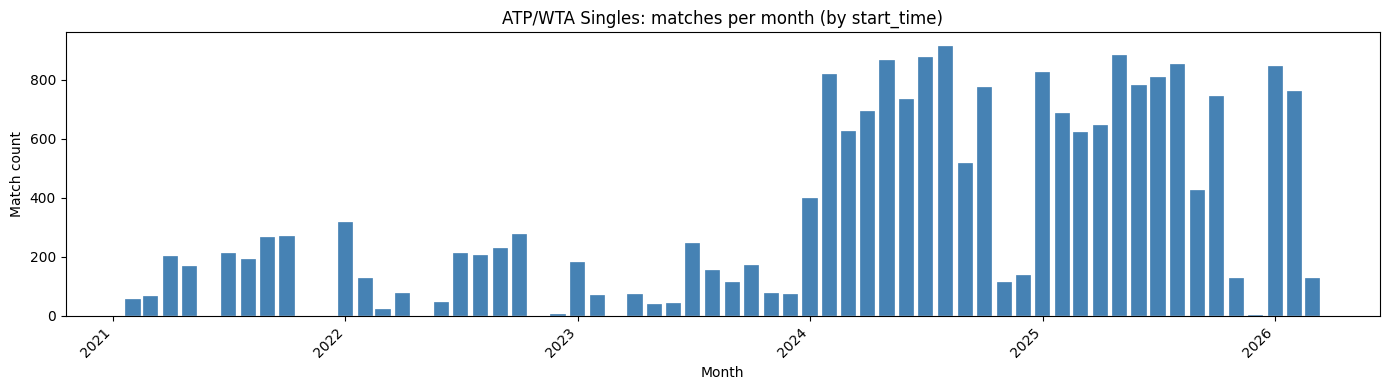

In [16]:
# One row per match → count by calendar month of start_time
_st = pd.to_datetime(event_data["start_time"], utc=True, errors="coerce")
_ok = _st.notna()
if not _ok.all():
    n_bad = int((~_ok).sum())
    print(f"Warning: {n_bad} rows with missing/unparseable start_time excluded")

monthly = (
    event_data.loc[_ok]
    .assign(_month=_st[_ok].dt.to_period("M"))
    .groupby("_month", sort=True)
    .size()
)
monthly.index = monthly.index.to_timestamp()  # plot-friendly x axis

if len(monthly) >= 2:
    bar_width = (monthly.index[1] - monthly.index[0]).days * 0.85
else:
    bar_width = 24

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(
    monthly.index,
    monthly.values,
    width=bar_width,
    align="center",
    color="steelblue",
    edgecolor="white",
    linewidth=0.2,
)
ax.set_title("ATP/WTA Singles: matches per month (by start_time)")
ax.set_xlabel("Month")
ax.set_ylabel("Match count")
fig.autofmt_xdate(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
#Reliable data starts in 2024
_cutoff = pd.Timestamp("2024-01-01", tz="UTC")
_st = pd.to_datetime(event_data["start_time"], utc=True, errors="coerce")
event_data = event_data.loc[_st >= _cutoff].copy()

In [18]:
# Evaluate if winner_id is present for each match
col = "winner_id"
s = event_data[col]

# Raw nulls (pandas / numpy)
is_null = s.isna()

# String cleanup: treat blanks and common placeholders as missing
if s.dtype == object or pd.api.types.is_string_dtype(s):
    str_s = s.astype("string")
    stripped = str_s.str.strip()
    is_blank = stripped == ""
    is_placeholder = stripped.str.lower().isin(
        {"nan", "none", "null", "n/a", "na", "#n/a", ""}
    )
else:
    stripped = s.astype("string")
    is_blank = stripped.str.strip() == ""
    is_placeholder = pd.Series(False, index=s.index)

# Sportradar-style competitor id (adjust if your IDs differ)
looks_like_id = stripped.str.match(r"^sr:competitor:\d+$", na=False)

missing_winner = is_null | is_blank | is_placeholder | ~looks_like_id

print(f"rows: {len(event_data):,}")
print(f"missing winner_id (null/blank/placeholder): {(is_null | is_blank | is_placeholder).sum():,}")
print(f"winner_id not matching sr:competitor:<digits>: {(~looks_like_id & ~(is_null | is_blank | is_placeholder)).sum():,}")
print(f"any row without a proper winner id: {missing_winner.sum():,}")

# Quick look at odd values
odd = event_data.loc[missing_winner, [col]].drop_duplicates()
print("\nSample distinct missing/bad values:")
print(odd.head(20))

rows: 16,638
missing winner_id (null/blank/placeholder): 150
winner_id not matching sr:competitor:<digits>: 0
any row without a proper winner id: 150

Sample distinct missing/bad values:
     winner_id
5913      None


In [19]:
# Remove rows without a winner id
event_data = event_data.loc[~missing_winner].copy()

In [20]:
event_data['match_status'].value_counts()

match_status
ended       16181
retired       253
walkover       54
Name: count, dtype: int64

In [21]:
# Use the tournament level to adjust K factor during Elo calculation
def get_competition_data() -> pd.DataFrame:
    _competition_table = SportradarManager().get_table_id("competitions")
    query = f"""
    SELECT * 
    FROM `{_competition_table}`
    """
    return client.query(query).to_dataframe()

competition_data = get_competition_data()

In [22]:
comp_level = competition_data[["id", "level"]]
event_data = event_data.merge(
  comp_level,
  how="left",
  left_on="competition_id",
  right_on="id",
).drop(columns=["id"])

In [23]:
event_data['level'].value_counts()

level
grand_slam               3808
atp_250                  2813
wta_1000                 2236
wta_250                  2232
atp_1000                 1994
atp_500                  1634
wta_500                  1587
atp_world_tour_finals       6
atp_next_generation         6
wta_championships           6
Name: count, dtype: int64

In [24]:
# Not enough data from these tournaments
exclude_levels = [
    "atp_world_tour_finals",
    "atp_next_generation",
    "wta_championships",
]
event_data = event_data[~event_data["level"].isin(exclude_levels)].copy()

In [25]:
# Split into mens and womens data
mens_event_data = event_data[event_data['competition_gender'] == 'men'].sort_values(by='start_time', ascending=True)
womens_event_data = event_data[event_data['competition_gender'] == 'women'].sort_values(by='start_time', ascending=True)

______
#### Match Elo Tuning (0–100 scale)

| Parameter | Role |
|-----------|------|
| **`s`** | Logistic **scale** in . **Lower `s`** → stronger favorite for the same rating gap → **smaller** \((1 - E)\) for the favorite → **less** gain on expected wins (and **less** loss on expected losses). **Higher `s`** does the opposite (softer favorites, **larger** moves for the same \(K\)). |
| **`K_base`** | Global step size: scales **all** rating changes from the Elo term \(K(S - E)\). **Higher** → faster, noisier evolution. |
| **`w_match`** | Per-match multiplier (e.g. by tournament level): effective \(K = K_{\text{base}} \times w_{\text{match}}\). **Higher** at Slams/M1000 etc. → those matches move ratings more. |
| **Winner dampening (ceiling)** | Optional multiplier on the **winner’s** \(\Delta\) based on proximity to **`R_max`**. **Reduces** gains for players **already near the top** so ratings **ease toward** the high end without needing huge \(K\) cuts. |
| **Loser floor dampening** | Separate multiplier on the **loser’s** (negative) \(\Delta\) for players **already near the bottom**. **Softens** how far very low ratings can fall. |

**Note:** Standard Elo already moves **favorites less** on wins and **underdogs less** on losses via \((1-E)\) and symmetry. **`s`** controls how strong that effect is; **`K_base`** and **`w_match`** set the overall magnitude; **winner ceiling dampening** adds extra shrink for **high** ratings; **loser floor dampening** adds extra shrink for **low** ratings only if you implement and enable it.

**Zero-sum:** Pure symmetric Elo preserves total rating; optional **asymmetric** dampening on winner vs loser can break exact zero-sum (usually mildly).

TUNING: {'s': 60.0, 'K_base': 1.0, 'w_match': 1.0, 'R_max': 100.0, 'gamma_win': 0.25, 'use_winner_dampen': True, 'use_loser_dampen': False, 'gamma_lose': 1.0, 'use_loser_floor_dampen': True, 'gamma_floor': 0.25, 'r_floor_eps': 1.0}

favorite 92 vs 82 (10 gap)
  E_winner=0.5948  Δ_w=+0.2155  Δ_l=-0.3856  → 92.0→92.2155, 82.0→81.6144

even 92 vs 92
  E_winner=0.5000  Δ_w=+0.2659  Δ_l=-0.4897  → 92.0→92.2659, 92.0→91.5103

underdog 72 beats 82
  E_winner=0.4052  Δ_w=+0.4327  Δ_l=-0.5660  → 72.0→72.4327, 82.0→81.4340

huge upset 50 vs 90
  E_winner=0.1773  Δ_w=+0.6918  Δ_l=-0.8014  → 50.0→50.6918, 90.0→89.1986

tight 88 vs 86
  E_winner=0.5192  Δ_w=+0.2830  Δ_l=-0.4630  → 88.0→88.2830, 86.0→85.5370

favorite 54 beats 32
  E_winner=0.6994  Δ_w=+0.2476  Δ_l=-0.2261  → 54.0→54.2476, 32.0→31.7739

underdog 32 beats 54
  E_winner=0.3006  Δ_w=+0.6351  Δ_l=-0.5995  → 32.0→32.6351, 54.0→53.4005

underdog 45 beats 50
  E_winner=0.4522  Δ_w=+0.4718  Δ_l=-0.4607  → 45.0→45.4718, 50.0→49.5393

favorit

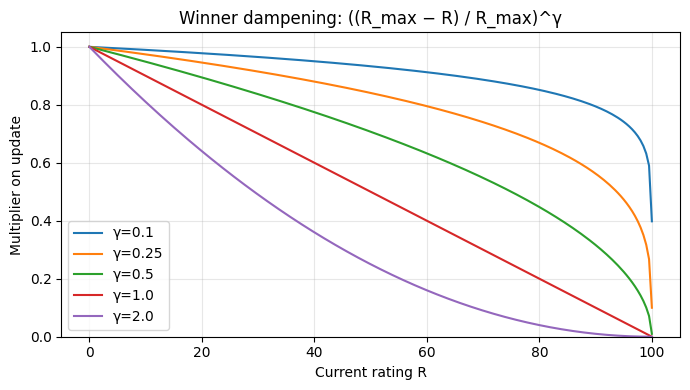

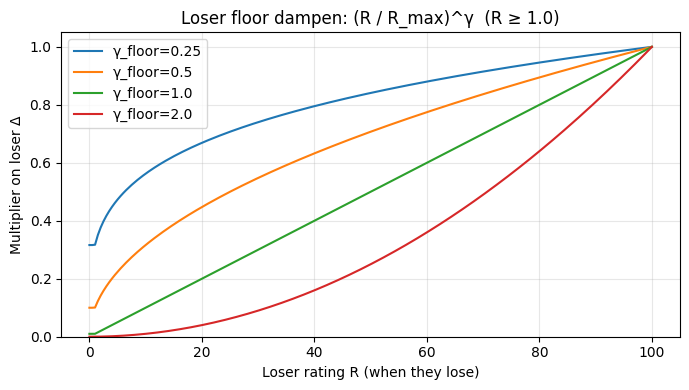

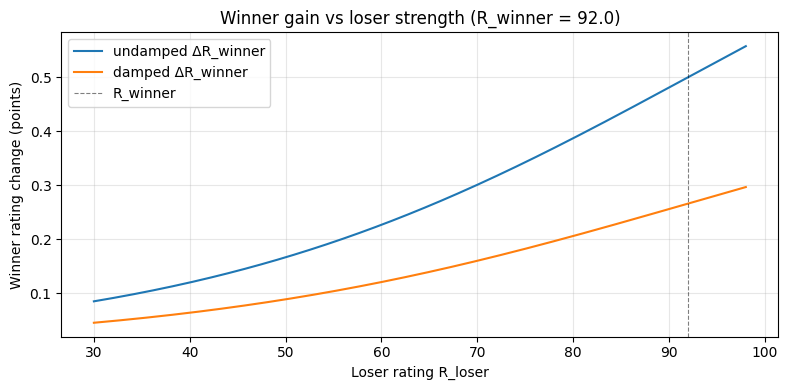

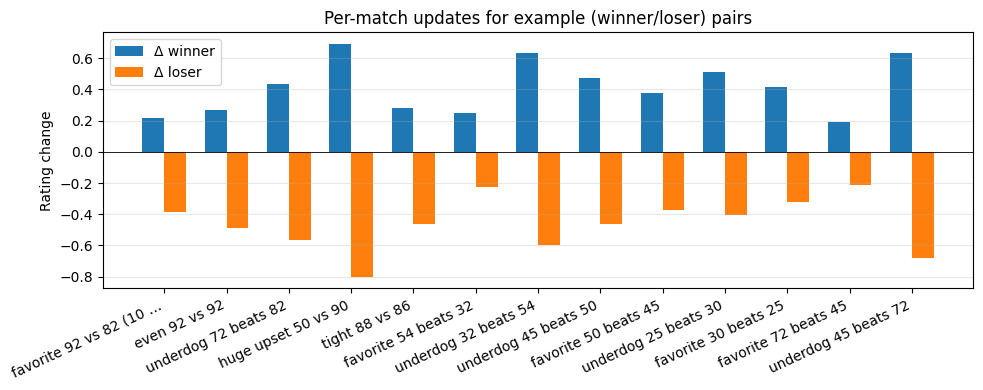

In [26]:
"""
Isolated Elo + dampening playground (0–100 scale).
Adjust TUNING below and re-run the cell.
"""
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# TUNING — edit these
# ---------------------------------------------------------------------------
TUNING = {
    "s": 60.0,           # logistic scale: smaller => stronger favorite for same rating gap
    "K_base": 1.0,       # base K before tournament weight / dampening
    "w_match": 1.0,      # tournament weight multiplier (slam vs 250)
    "R_max": 100.0,      # ceiling for dampening (your ladder top)
    # winner-only power dampen: mult = ((R_max - R_w) / R_max) ** gamma_win
    "gamma_win": 0.25,    # 1 = linear toward 0 at R_max; >1 = stronger near top
    "use_winner_dampen": True,
    # optional: also dampen loser side (usually keep False so upsets still bite)
    "use_loser_dampen": False,
    "gamma_lose": 1.0,
    # Loser: floor-style (low R_l → smaller loss). Protects basement ratings.
    "use_loser_floor_dampen": True,
    "gamma_floor": 0.25,
    "r_floor_eps": 1.0,  # min R used in (R/R_max)^γ so R=0 doesn't zero the mult oddly
}

# Example scenarios: (R_winner, R_loser) — isolated, not real data
SCENARIOS = [
    (92, 82, "favorite 92 vs 82 (10 gap)"),
    (92, 92, "even 92 vs 92"),
    (72, 82, "underdog 72 beats 82"),
    (50, 90, "huge upset 50 vs 90"),
    (88, 86, "tight 88 vs 86"),
    (54, 32, "favorite 54 beats 32"),
    (32, 54, "underdog 32 beats 54"),
    (45, 50, "underdog 45 beats 50"),
    (50, 45, "favorite 50 beats 45"),
    (25, 30, "underdog 25 beats 30"),
    (30, 25, "favorite 30 beats 25"),
    (72, 45, "favorite 72 beats 45"),
    (45, 72, "underdog 45 beats 72"),
]

# ---------------------------------------------------------------------------
# Core math
# ---------------------------------------------------------------------------

def expected_winner(r_w: float, r_l: float, s: float) -> float:
    """Expected score for the winner slot vs loser (winner is 'A' in Elo formula)."""
    return 1.0 / (1.0 + 10 ** ((r_l - r_w) / s))


def dampen_mult(r, r_max: float, gamma: float):
    """1 near r=0, → 0 as r → r_max. Works for scalar or array r."""
    r = np.asarray(r, dtype=float)
    r = np.clip(r, 0.0, r_max - 1e-9)
    return np.maximum(0.0, (r_max - r) / r_max) ** gamma

def dampen_floor_mult(r, r_max: float, gamma: float, r_eps: float):
  """Near r=0 → small mult (shrink loss); near r_max → ~1. Scalar or array."""
  r = np.asarray(r, dtype=float)
  r = np.clip(r, r_eps, r_max)
  return (r / r_max) ** gamma


def delta_standard(r_w: float, r_l: float, k: float, s: float) -> tuple[float, float]:
    """Symmetric Elo: returns (delta_winner, delta_loser) after a win for r_w."""
    e_w = expected_winner(r_w, r_l, s)
    d = k * (1.0 - e_w)
    return d, -d


def delta_damped_winner(
    r_w: float,
    r_l: float,
    k: float,
    s: float,
    r_max: float,
    gamma_win: float,
    dampen_w: bool,
    dampen_l_ceiling: bool,
    gamma_lose: float,
    dampen_l_floor: bool,
    gamma_floor: float,
    r_floor_eps: float,
) -> tuple[float, float]:
    e_w = expected_winner(r_w, r_l, s)
    raw_w = k * (1.0 - e_w)
    raw_l = -raw_w

    m_w = dampen_mult(r_w, r_max, gamma_win) if dampen_w else 1.0

    m_l = 1.0
    if dampen_l_ceiling:
        m_l *= dampen_mult(r_l, r_max, gamma_lose)
    if dampen_l_floor:
        m_l *= dampen_floor_mult(r_l, r_max, gamma_floor, r_floor_eps)

    d_w = raw_w * m_w
    d_l = raw_l * m_l
    return d_w, d_l


def apply_match(
    r_w: float,
    r_l: float,
    tun: dict,
) -> dict:
    k = tun["K_base"] * tun["w_match"]
    if (
      tun["use_winner_dampen"]
      or tun["use_loser_dampen"]
      or tun["use_loser_floor_dampen"]
    ):
      d_w, d_l = delta_damped_winner(
          r_w,
          r_l,
          k,
          tun["s"],
          tun["R_max"],
          tun["gamma_win"],
          tun["use_winner_dampen"],
          tun["use_loser_dampen"],
          tun["gamma_lose"],
          tun["use_loser_floor_dampen"],
          tun["gamma_floor"],
          tun["r_floor_eps"],
      )
    else:
        d_w, d_l = delta_standard(r_w, r_l, k, tun["s"])
    e_w = expected_winner(r_w, r_l, tun["s"])
    return {
        "E_winner": e_w,
        "delta_w": d_w,
        "delta_l": d_l,
        "new_w": r_w + d_w,
        "new_l": r_l + d_l,
    }


# ---------------------------------------------------------------------------
# Plot 1 — dampening multiplier vs rating
# ---------------------------------------------------------------------------
def plot_dampening_curves(r_max: float, gammas: list[float]):
    r = np.linspace(0, r_max - 0.01, 200)
    fig, ax = plt.subplots(figsize=(7, 4))
    for g in gammas:
        ax.plot(r, dampen_mult(r, r_max, g), label=f"γ={g}")
    ax.set_xlabel("Current rating R")
    ax.set_ylabel("Multiplier on update")
    ax.set_title("Winner dampening: ((R_max − R) / R_max)^γ")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

def plot_floor_dampening_curves(r_max: float, gammas: list[float], r_eps: float):
  r = np.linspace(0.01, r_max - 0.01, 200)
  fig, ax = plt.subplots(figsize=(7, 4))
  for g in gammas:
      ax.plot(r, dampen_floor_mult(r, r_max, g, r_eps), label=f"γ_floor={g}")
  ax.set_xlabel("Loser rating R (when they lose)")
  ax.set_ylabel("Multiplier on loser Δ")
  ax.set_title(f"Loser floor dampen: (R / R_max)^γ  (R ≥ {r_eps})")
  ax.legend()
  ax.set_ylim(0, 1.05)
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  return fig


# ---------------------------------------------------------------------------
# Plot 2 — winner gain vs loser rating (fixed high winner)
# ---------------------------------------------------------------------------
def plot_winner_gain_vs_loser_rating(
    r_w_fixed: float,
    r_l_grid: np.ndarray,
    tun: dict,
):
    k = tun["K_base"] * tun["w_match"]
    e_w = np.array([expected_winner(r_w_fixed, rl, tun["s"]) for rl in r_l_grid])
    raw = k * (1.0 - e_w)
    m_w = dampen_mult(r_w_fixed, tun["R_max"], tun["gamma_win"]) if tun["use_winner_dampen"] else 1.0
    damped = raw * m_w

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(r_l_grid, raw, label="undamped ΔR_winner", color="C0")
    if tun["use_winner_dampen"]:
        ax.plot(r_l_grid, damped, label="damped ΔR_winner", color="C1")
    ax.axvline(r_w_fixed, color="k", ls="--", lw=0.8, alpha=0.5, label="R_winner")
    ax.set_xlabel("Loser rating R_loser")
    ax.set_ylabel("Winner rating change (points)")
    ax.set_title(f"Winner gain vs loser strength (R_winner = {r_w_fixed})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Plot 3 — compare scenarios table + bar chart
# ---------------------------------------------------------------------------
def summarize_scenarios(tun: dict, scenarios: list[tuple[float, float, str]]):
    rows = []
    for rw, rl, label in scenarios:
        u = apply_match(rw, rl, tun)
        rows.append(
            {
                "scenario": label,
                "R_w": rw,
                "R_l": rl,
                "E_w": u["E_winner"],
                "Δ_w": u["delta_w"],
                "Δ_l": u["delta_l"],
                "new_w": u["new_w"],
                "new_l": u["new_l"],
            }
        )
    return rows


def plot_scenario_bars(rows: list[dict]):
    labels = [r["scenario"][:22] + "…" if len(r["scenario"]) > 22 else r["scenario"] for r in rows]
    x = np.arange(len(labels))
    dw = [r["Δ_w"] for r in rows]
    dl = [r["Δ_l"] for r in rows]

    fig, ax = plt.subplots(figsize=(10, 4))
    w = 0.35
    ax.bar(x - w / 2, dw, width=w, label="Δ winner")
    ax.bar(x + w / 2, dl, width=w, label="Δ loser")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel("Rating change")
    ax.set_title("Per-match updates for example (winner/loser) pairs")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------
np.set_printoptions(precision=4, suppress=True)

print("TUNING:", TUNING)
print()
rows = summarize_scenarios(TUNING, SCENARIOS)
for r in rows:
    print(
        f"{r['scenario']}\n"
        f"  E_winner={r['E_w']:.4f}  Δ_w={r['Δ_w']:+.4f}  Δ_l={r['Δ_l']:+.4f}  "
        f"→ {r['R_w']:.1f}→{r['new_w']:.4f}, {r['R_l']:.1f}→{r['new_l']:.4f}\n"
    )

plot_dampening_curves(TUNING["R_max"], gammas=[0.1, 0.25,0.5, 1.0, 2.0])
plt.show()

plot_floor_dampening_curves(
  TUNING["R_max"],
  gammas=[0.25, 0.5, 1.0, 2.0],
  r_eps=TUNING["r_floor_eps"],
)
plt.show()

r_grid = np.linspace(30, 98, 200)
plot_winner_gain_vs_loser_rating(92.0, r_grid, TUNING)
plt.show()

plot_scenario_bars(rows)
plt.show()

# Optional: overlay undamped vs damped for the same 92-vs-grid (second line already in plot 2).
# Flip use_winner_dampen False/True in TUNING and re-run to compare figures side by side.

#### ELO Calculations

The above ELO tuning methods converted to elo.py module

In [27]:
from refined_tables.elo import EloUpdateConfig, process_matches, TOURNAMENT_WEIGHTS

cfg = EloUpdateConfig()  # or override fields

# Seed from your initialized table, e.g. competitor_id -> elo_init
mens_ratings = mens_competitors_with_elo.set_index("competitor_id")["elo_init"].to_dict()

# Add loser_id column
w = mens_event_data["winner_id"]
h = mens_event_data["home_competitor_id"]
a = mens_event_data["away_competitor_id"]
mens_event_data["loser_id"] = np.where(w == h, a, np.where(w == a, h, np.nan))

# Add winner_name and loser_name columns
mens_event_data["winner_name"] = np.where(mens_event_data["home_competitor_id"] == mens_event_data["winner_id"], mens_event_data["home_competitor_name"], mens_event_data["away_competitor_name"])
mens_event_data["loser_name"] = np.where(mens_event_data["home_competitor_id"] == mens_event_data["loser_id"], mens_event_data["home_competitor_name"], mens_event_data["away_competitor_name"])

# Rename tournament_level column
mens_event_data = mens_event_data.rename(columns={"level": "tournament_level"})


In [28]:
history = process_matches(
    mens_event_data,
    mens_ratings,
    config=cfg,
    winner_col="winner_id",
    loser_col="loser_id",
    level_col="tournament_level",
    sort_by="start_time",
    event_id_col="sport_event_id",
    winner_name_col="winner_name",
    loser_name_col="loser_name",
    return_history=True,
)

In [ ]:
#Alcaraz Rating as highest player
mens_ratings['sr:competitor:407573']

92.31430739495137

_______
#### Upload ELO to BQ

In [41]:
history.dtypes

event_id        object
winner_name     object
loser_name      object
winner_id       object
loser_id        object
w_match        float64
r_w_before     float64
r_l_before     float64
delta_w        float64
delta_l        float64
r_w_after      float64
r_l_after      float64
dtype: object

In [46]:
mens_ratings_df = pd.DataFrame(mens_ratings)

ValueError: If using all scalar values, you must pass an index

In [45]:
mens_ratings

{'sr:competitor:51141': 43.783232079496,
 'sr:competitor:16972': 31.914151239263294,
 'sr:competitor:15853': 27.880047681278512,
 'sr:competitor:17038': 33.25135358741937,
 'sr:competitor:69500': 33.241941476820394,
 'sr:competitor:38183': 39.48359592150275,
 'sr:competitor:16192': 24.017218016919443,
 'sr:competitor:77223': 39.373275770396724,
 'sr:competitor:123694': 36.9336847349761,
 'sr:competitor:48163': 27.093461479413044,
 'sr:competitor:206889': 31.383521209501858,
 'sr:competitor:223998': 30.051272222969253,
 'sr:competitor:14736': 30.949596527487135,
 'sr:competitor:130398': 47.92111139841261,
 'sr:competitor:51009': 38.750890935595926,
 'sr:competitor:254383': 53.51724849455982,
 'sr:competitor:73987': 26.06495876763678,
 'sr:competitor:161262': 43.8861502514209,
 'sr:competitor:300540': 56.030257353490214,
 'sr:competitor:119140': 34.81965145726882,
 'sr:competitor:196440': 33.27164337115497,
 'sr:competitor:503814': 46.70308744928217,
 'sr:competitor:341218': 33.654559676